In [1]:
%pip install federated-rsf

Note: you may need to restart the kernel to use updated packages.


In [2]:
import ipywidgets as widgets
from sksurv.datasets import (
    load_aids,
    load_breast_cancer,
    load_flchain,
    load_gbsg2,
    load_whas500,
    load_veterans_lung_cancer,
)
from IPython.display import display
from federated_rsf.models import (
    LocalRandomSurvivalForest,
    FederatedRandomSurvivalForest,
)
from federated_rsf.schema import DatasetSchema, SchemaAligner, SchemaCreator
from federated_rsf.testing import federate_data
from sksurv.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

desc_width = "130px"

dataset_name_to_loader = {
    "aids": load_aids,
    "breast_cancer": load_breast_cancer,
    "flchain": load_flchain,
    "gbsg2": load_gbsg2,
    "whas500": load_whas500,
    "veterans_lung_cancer": load_veterans_lung_cancer,
}

dataset_selector = widgets.Dropdown(
    options=dataset_name_to_loader,
    value=load_gbsg2,
    description="Dataset:",
    style={"description_width": desc_width},
)
display(dataset_selector)

test_size_selector = widgets.FloatSlider(
    value=0.3,
    min=0.1,
    max=0.9,
    step=0.05,
    description="Test Size:",
    style={"description_width": desc_width},
)
display(test_size_selector)

drop_feature_percent_selector = widgets.IntSlider(
    value=30,
    min=0,
    max=100,
    step=5,
    description="Dropped Features (%):",
    style={"description_width": desc_width},
)
display(drop_feature_percent_selector)

client_count_selector = widgets.IntSlider(
    value=10,
    min=2,
    max=20,
    step=1,
    description="Client Count:",
    style={"description_width": desc_width},
)
display(client_count_selector)

tree_count_selector = widgets.IntSlider(
    value=100,
    min=10,
    max=1000,
    step=10,
    description="Local Tree Count:",
    style={"description_width": desc_width},
)
display(tree_count_selector)

max_depth_selector = widgets.SelectionSlider(
    options=list(range(1, 11)) + ["None"],
    value=3,
    description="Max Depth:",
    style={"description_width": desc_width},
)
display(max_depth_selector)

update_method_selector = widgets.Dropdown(
    options=["all", "constant"],
    value="all",
    description="Update Method:",
    style={"description_width": desc_width},
)
display(update_method_selector)


Dropdown(description='Dataset:', index=3, options={'aids': <function load_aids at 0x0000027C5110FF60>, 'breast…

FloatSlider(value=0.3, description='Test Size:', max=0.9, min=0.1, step=0.05, style=SliderStyle(description_wi…

IntSlider(value=30, description='Dropped Features (%):', step=5, style=SliderStyle(description_width='130px'))

IntSlider(value=10, description='Client Count:', max=20, min=2, style=SliderStyle(description_width='130px'))

IntSlider(value=100, description='Local Tree Count:', max=1000, min=10, step=10, style=SliderStyle(description…

SelectionSlider(description='Max Depth:', index=2, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'None'), style=Slid…

Dropdown(description='Update Method:', options=('all', 'constant'), style=DescriptionStyle(description_width='…

In [3]:
def convert_to_federated_datasets(
    X, Y, n_clients, drop_feature_percentage=0.3, random_state=0, shuffle=True
):
    X_list, Y_list = federate_data(
        X,
        Y,
        clients=n_clients,
        drop_feature_percentage=drop_feature_percentage,
        random_state=random_state,
        shuffle=shuffle,
    )
    X_list = [OneHotEncoder().fit_transform(X) for X in X_list]

    schema_list = [DatasetSchema(X.columns) for X in X_list]
    schema_creator = SchemaCreator()
    federated_schemas = schema_creator.fit_transform(schema_list)

    X_aligned_list = []
    local_schema_aligners = []
    for X_local, schema in zip(X_list, federated_schemas):
        aligner = SchemaAligner().fit(schema)
        X_aligned = aligner.transform(X_local)
        X_aligned_list.append(X_aligned)
        local_schema_aligners.append(aligner)
    return X_aligned_list, Y_list


n_clients = client_count_selector.value

X, Y = dataset_selector.value()


X_list, Y_list = convert_to_federated_datasets(
    X,
    Y,
    n_clients,
    drop_feature_percentage=drop_feature_percent_selector.value / 100,
    random_state=0,
)

In [4]:
def split_data(X_list, Y_list, test_size: float):
    X_trains, X_tests, Y_trains, Y_tests = [], [], [], []

    for X_local, Y_local in zip(X_list, Y_list):
        X_train, X_test, Y_train, Y_test = train_test_split(
            X_local, Y_local, test_size=test_size, random_state=0
        )
        X_trains.append(X_train)
        X_tests.append(X_test)
        Y_trains.append(Y_train)
        Y_tests.append(Y_test)

    return X_trains, Y_trains, X_tests, Y_tests


def fit_and_federate_models(X_trains, Y_trains, local_models):
    for X_train, Y_train, local_model in zip(X_trains, Y_trains, local_models):
        local_model.fit(X_train, Y_train)

    federated_model = FederatedRandomSurvivalForest(local_models=local_models)
    federated_model.distribute_trees()

    return local_models


def train_global_model(X_trains, Y_trains, global_model):
    X_global_train = pd.concat(X_trains, ignore_index=True)
    Y_global_train = np.concatenate(Y_trains)

    global_model.fit(X_global_train, Y_global_train)

    return global_model


local_models = [
    LocalRandomSurvivalForest(
        n_estimators=tree_count_selector.value,
        max_depth=max_depth_selector.value,
        random_state=0,
        update_method=update_method_selector.value,
    )
    for _ in range(n_clients)
]
global_model = LocalRandomSurvivalForest(
    n_estimators=4 * tree_count_selector.value,
    max_depth=max_depth_selector.value,
    random_state=0,
    update_method=update_method_selector.value,
)

X_trains, Y_trains, X_tests, Y_tests = split_data(
    X_list, Y_list, test_size_selector.value
)

local_models = fit_and_federate_models(X_trains, Y_trains, local_models)
global_model = train_global_model(X_trains, Y_trains, global_model)

In [5]:
def evaluate_models_text(local_models, global_model, X_tests, Y_tests):
    for i, (local_model, X_test, Y_test) in enumerate(
        zip(local_models, X_tests, Y_tests)
    ):
        global_c_index = global_model.score(X_test, Y_test)
        print(f"Client {i + 1}")
        print(f"Global model C-index: {global_c_index:.4f}")
        local_model.use_local_estimators()
        c_index = local_model.score(X_test, Y_test)
        print(f"Local model C-index: {c_index:.4f}")
        local_model.use_federated_estimators()
        federated_c_index = local_model.score(X_test, Y_test)
        if global_c_index < federated_c_index > c_index:
            color = "\033[32m"  # Green
        elif global_c_index >= federated_c_index <= c_index:
            color = "\033[31m"  # Red
        else:
            color = "\033[33m"  # Yellow
        print(f"Federated model C-index: {color}{federated_c_index:.4f}\033[0m")
        print(f"Number of estimators in federated model: {local_model.n_estimators}")
        print("-" * 30)


evaluate_models_text(local_models, global_model, X_tests, Y_tests)

Client 1
Global model C-index: 0.6250
Local model C-index: 0.6471
Federated model C-index: 0.6618
Number of estimators in federated model: 469
------------------------------
Client 2
Global model C-index: 0.7468
Local model C-index: 0.7089
Federated model C-index: 0.6962
Number of estimators in federated model: 262
------------------------------
Client 3
Global model C-index: 0.7612
Local model C-index: 0.8209
Federated model C-index: 0.7463
Number of estimators in federated model: 441
------------------------------
Client 4
Global model C-index: 0.7297
Local model C-index: 0.7477
Federated model C-index: 0.7748
Number of estimators in federated model: 256
------------------------------
Client 5
Global model C-index: 0.6471
Local model C-index: 0.6324
Federated model C-index: 0.6912
Number of estimators in federated model: 502
------------------------------
Client 6
Global model C-index: 0.5304
Local model C-index: 0.5826
Federated model C-index: 0.5043
Number of estimators in federate

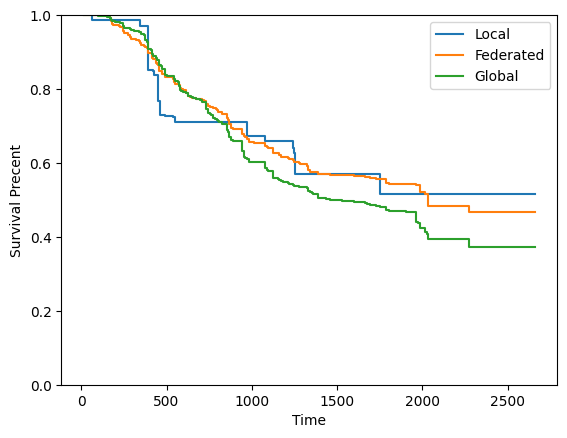

In [6]:
client_index = 0
sample_index = 0
local_models[client_index].use_local_estimators()
local_surv = local_models[client_index].predict_survival_function(X_tests[client_index].iloc[sample_index:1+sample_index])
plt.step(local_surv[0].x, local_surv[0](local_surv[0].x), label="Local")

local_models[client_index].use_federated_estimators()
fed_surv = local_models[client_index].predict_survival_function(X_tests[client_index].iloc[sample_index:1+sample_index])
plt.step(fed_surv[0].x, fed_surv[0](fed_surv[0].x), label="Federated")

global_surv = global_model.predict_survival_function(X_tests[client_index].iloc[sample_index:1+sample_index])
plt.step(global_surv[0].x, global_surv[0](global_surv[0].x), label="Global")

plt.ylim(0, 1)
plt.xlabel("Time")
plt.ylabel("Survival Precent")
plt.legend()
plt.show()

In [7]:
def collect_c_indexes(
    repetitions: int,
    local_tree_count: int,
    global_tree_count: int,
    max_depth: int,
    client_count: int,
    drop_feature_percent: int,
    update_method: str,
    test_size: float,
):
    c_indexes = {"local": [], "federated": [], "global": []}
    for random_state in range(repetitions):
        local_models = [
            LocalRandomSurvivalForest(
                n_estimators=local_tree_count,
                max_depth=max_depth,
                random_state=random_state,
                update_method=update_method,
            )
            for _ in range(client_count)
        ]
        global_model = LocalRandomSurvivalForest(
            n_estimators=global_tree_count,
            max_depth=max_depth,
            random_state=random_state,
            update_method=update_method,
        )

        X_list, Y_list = convert_to_federated_datasets(
            X,
            Y,
            client_count,
            drop_feature_percentage=drop_feature_percent / 100,
            random_state=random_state,
        )
        X_trains, Y_trains, X_tests, Y_tests = split_data(
            X_list, Y_list, test_size
        )

        local_models = fit_and_federate_models(X_trains, Y_trains, local_models)
        global_model = train_global_model(X_trains, Y_trains, global_model)

        for local_model, X_test, Y_test in zip(local_models, X_tests, Y_tests):
            global_c_index = global_model.score(X_test, Y_test)
            c_indexes["global"].append(global_c_index)
            local_model.use_local_estimators()
            c_index = local_model.score(X_test, Y_test)
            c_indexes["local"].append(c_index)
            local_model.use_federated_estimators()
            federated_c_index = local_model.score(X_test, Y_test)
            c_indexes["federated"].append(federated_c_index)

    return c_indexes

display(tree_count_selector)
display(max_depth_selector)
display(client_count_selector)
display(drop_feature_percent_selector)
display(update_method_selector)
display(test_size_selector)


c_indexes = collect_c_indexes(
    repetitions=10,
    local_tree_count=tree_count_selector.value,
    global_tree_count=4 * tree_count_selector.value,
    max_depth=max_depth_selector.value,
    client_count=client_count_selector.value,
    drop_feature_percent=drop_feature_percent_selector.value / 100,
    update_method=update_method_selector.value,
    test_size=test_size_selector.value,
)

IntSlider(value=100, description='Local Tree Count:', max=1000, min=10, step=10, style=SliderStyle(description…

SelectionSlider(description='Max Depth:', index=2, options=(1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 'None'), style=Slid…

IntSlider(value=10, description='Client Count:', max=20, min=2, style=SliderStyle(description_width='130px'))

IntSlider(value=30, description='Dropped Features (%):', step=5, style=SliderStyle(description_width='130px'))

Dropdown(description='Update Method:', options=('all', 'constant'), style=DescriptionStyle(description_width='…

FloatSlider(value=0.30000000000000004, description='Test Size:', max=0.9, min=0.1, step=0.05, style=SliderStyl…

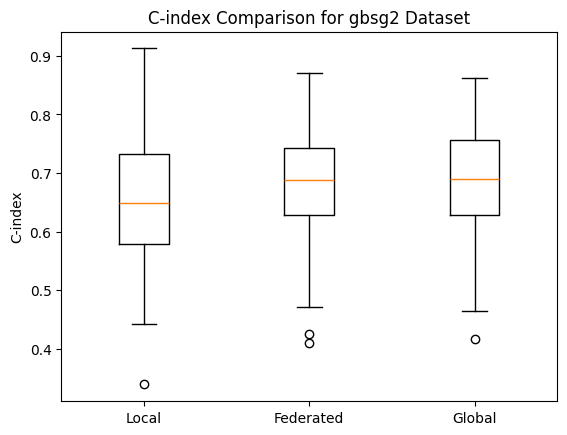

In [8]:
from matplotlib import pyplot as plt

plt.boxplot(
    [c_indexes["local"], c_indexes["federated"], c_indexes["global"]],
    tick_labels=["Local", "Federated", "Global"],
)
plt.ylabel("C-index")
plt.title(f"C-index Comparison for {dataset_selector.label} Dataset")
plt.savefig(f"single_dataset_figures/{dataset_selector.label}_c_index_comparison.png")
plt.show()
